# FER-2013 Emotion Recognition — ConvNeXt-Tiny Fine-Tuning


In [2]:
import os
import math
import json
import time
import random
import shutil
import zipfile
import urllib.request
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from google.colab import drive, files

drive.mount("/content/drive")

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type != "cuda":
    raise RuntimeError("GPU is not enabled. In Colab: Runtime -> Change runtime type -> T4 GPU")

torch.backends.cudnn.benchmark = True
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

Mounted at /content/drive
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
# Configuration

DRIVE_DIR = Path("/content/drive/MyDrive/EmD")

COPY_TO_LOCAL = True
LOCAL_DIR = Path("/content/fer2013_data")

RUN_DIR = DRIVE_DIR / "fer2013_convnext_tiny"
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
FIGURE_DIR = RUN_DIR / "figures"
REPORT_DIR = RUN_DIR / "reports"

for p in [RUN_DIR, CHECKPOINT_DIR, FIGURE_DIR, REPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

LATEST_CKPT = CHECKPOINT_DIR / "latest_checkpoint.pt"
BEST_CKPT = CHECKPOINT_DIR / "best_model.pt"
WEIGHTS_ONLY = CHECKPOINT_DIR / "best_weights_only.pth"
HISTORY_CSV = REPORT_DIR / "training_history.csv"
METADATA_JSON = REPORT_DIR / "model_metadata.json"

SEED = 42
VAL_SPLIT = 0.20

IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2

MAX_EPOCHS = 40
MIN_EPOCHS_BEFORE_STOP = 12
EARLY_STOPPING_PATIENCE = 8
WARMUP_EPOCHS = 3

BACKBONE_LR = 3e-5
HEAD_LR = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.10
GRAD_CLIP = 1.0

RESUME = True
USE_AMP = True
USE_TTA = True

# Real-image inference:
MATCH_FER_48_RESOLUTION = True
FACE_PADDING = 0.22

print("Run directory:", RUN_DIR)
print("Latest checkpoint:", LATEST_CKPT)

Run directory: /content/drive/MyDrive/EmD/fer2013_convnext_tiny
Latest checkpoint: /content/drive/MyDrive/EmD/fer2013_convnext_tiny/checkpoints/latest_checkpoint.pt


In [4]:
# Reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

In [5]:
#  Find/copy/extract dataset automatically
def find_dataset_root(base):
    base = Path(base)

    if (base / "train").is_dir() and (base / "test").is_dir():
        return base

    if base.exists():
        for train_dir in base.rglob("train"):
            parent = train_dir.parent
            if (parent / "test").is_dir():
                return parent
    return None

drive_root = find_dataset_root(DRIVE_DIR)

if drive_root is None:
    zip_files = list(DRIVE_DIR.glob("*.zip"))
    if not zip_files:
        raise FileNotFoundError(
            f"No train/test folders and no ZIP file found inside {DRIVE_DIR}"
        )

    # Prefer a ZIP whose name contains FER if present.
    preferred = [p for p in zip_files if "fer" in p.name.lower()]
    zip_path = preferred[0] if preferred else zip_files[0]

    print("Extracting:", zip_path)
    LOCAL_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(LOCAL_DIR)

    DATA_ROOT = find_dataset_root(LOCAL_DIR)
else:
    if COPY_TO_LOCAL:
        print("Copying dataset from Drive to local Colab storage for faster training...")
        LOCAL_DIR.mkdir(parents=True, exist_ok=True)

        # dirs_exist_ok=True also repairs an interrupted partial copy.
        shutil.copytree(
            drive_root / "train",
            LOCAL_DIR / "train",
            dirs_exist_ok=True
        )
        shutil.copytree(
            drive_root / "test",
            LOCAL_DIR / "test",
            dirs_exist_ok=True
        )
        DATA_ROOT = LOCAL_DIR
    else:
        DATA_ROOT = drive_root

if DATA_ROOT is None:
    raise FileNotFoundError("Could not locate train/ and test/ after extraction/copy.")

TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)

Extracting: /content/drive/MyDrive/EmD/FER-2013.zip
DATA_ROOT: /content/fer2013_data
TRAIN_DIR: /content/fer2013_data/train
TEST_DIR: /content/fer2013_data/test


,emotion,train,test
0,angry,3995,958
1,disgust,436,111
2,fear,4097,1024
3,happy,7215,1774
4,neutral,4965,1233
5,sad,4830,1247
6,surprise,3171,831


Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total train: 28709
Total test : 7178


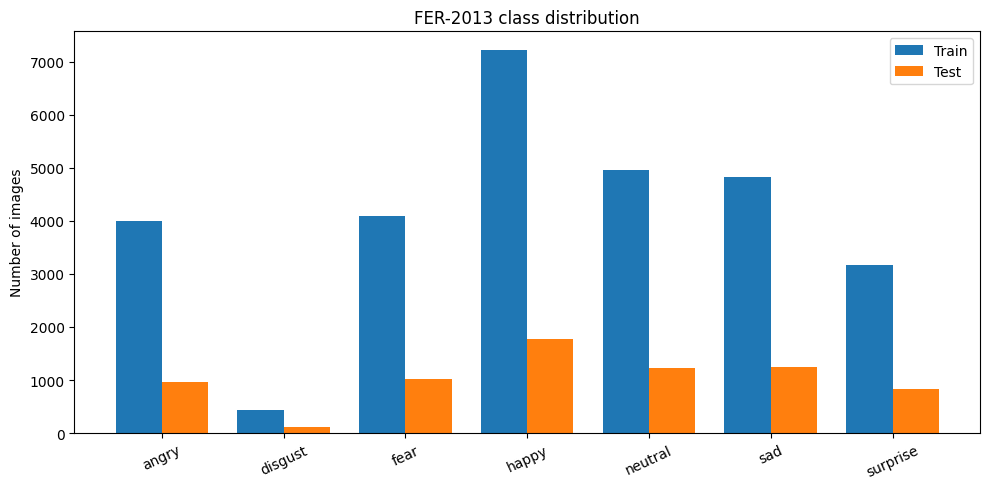

In [6]:
#  Verify classes and image counts
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

def count_images(folder):
    return sum(
        1 for p in Path(folder).rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTS
    )

class_names = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])

rows = []
for cls in class_names:
    rows.append({
        "emotion": cls,
        "train": count_images(TRAIN_DIR / cls),
        "test": count_images(TEST_DIR / cls),
    })

counts_df = pd.DataFrame(rows)
display(counts_df)

print("Classes:", class_names)
print("Total train:", int(counts_df["train"].sum()))
print("Total test :", int(counts_df["test"].sum()))

if len(class_names) != 7:
    print("WARNING: Expected 7 FER classes, but found", len(class_names))

# Figure: class distribution
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(counts_df))
w = 0.38
ax.bar(x - w/2, counts_df["train"], width=w, label="Train")
ax.bar(x + w/2, counts_df["test"], width=w, label="Test")
ax.set_xticks(x)
ax.set_xticklabels(counts_df["emotion"], rotation=25)
ax.set_ylabel("Number of images")
ax.set_title("FER-2013 class distribution")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_class_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

## Why these transforms?

FER-2013 images are only 48×48 and grayscale. The pretrained ConvNeXt model expects ImageNet-like 3-channel input, so each grayscale image is copied into 3 channels and resized to 224×224. Augmentation is deliberately mild so that facial expressions are not distorted beyond recognition.

In [7]:
# Image transforms
weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1

# ImageNet normalization used by the pretrained backbone.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        shear=3,
        fill=0,
    ),
    transforms.RandomAutocontrast(p=0.20),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(
        p=0.15,
        scale=(0.02, 0.08),
        ratio=(0.5, 2.0),
        value="random",
    ),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [8]:
# Stratified train/validation split
split_source = datasets.ImageFolder(TRAIN_DIR)
targets = np.array(split_source.targets)

sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=VAL_SPLIT,
    random_state=SEED
)
train_idx, val_idx = next(sss.split(np.zeros(len(targets)), targets))

train_full = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_full = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)
test_ds = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

assert train_full.classes == val_full.classes == test_ds.classes
class_names = train_full.classes
NUM_CLASSES = len(class_names)

train_ds = Subset(train_full, train_idx)
val_ds = Subset(val_full, val_idx)

print("Train samples:", len(train_ds))
print("Validation samples:", len(val_ds))
print("Test samples:", len(test_ds))
print("Classes:", class_names)

Train samples: 22967
Validation samples: 5742
Test samples: 7178
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [9]:
# Class-balanced loss weights
train_targets = targets[train_idx]
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)

raw_weights = 1.0 / np.sqrt(class_counts.astype(np.float64))
raw_weights = raw_weights / raw_weights.mean()
raw_weights = np.clip(raw_weights, 0.5, 3.5)

class_weights = torch.tensor(raw_weights, dtype=torch.float32, device=DEVICE)

weight_df = pd.DataFrame({
    "class": class_names,
    "train_count": class_counts,
    "loss_weight": raw_weights,
})
display(weight_df)

,class,train_count,loss_weight
0,angry,3196,0.805830
1,disgust,349,2.438564
2,fear,3277,0.795809
3,happy,5772,0.599630
4,neutral,3972,0.722840
5,sad,3864,0.732872
6,surprise,2537,0.904454


In [10]:
# DataLoaders
loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
)

train_loader = DataLoader(
    train_ds,
    shuffle=True,
    drop_last=True,
    **loader_kwargs
)

val_loader = DataLoader(
    val_ds,
    shuffle=False,
    drop_last=False,
    **loader_kwargs
)

test_loader = DataLoader(
    test_ds,
    shuffle=False,
    drop_last=False,
    **loader_kwargs
)

xb, yb = next(iter(train_loader))
print("Batch shape:", xb.shape)
print("Label shape:", yb.shape)

Batch shape: torch.Size([64, 3, 224, 224])
Label shape: torch.Size([64])


In [11]:
#  Build pretrained ConvNeXt-Tiny
def build_model(num_classes):
    model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(
        nn.Dropout(p=0.30),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_model(NUM_CLASSES).to(DEVICE)

# channels_last can improve convolution throughput on NVIDIA GPUs.
model = model.to(memory_format=torch.channels_last)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING,
)

optimizer = torch.optim.AdamW(
    [
        {"params": model.features.parameters(), "lr": BACKBONE_LR},
        {"params": model.classifier.parameters(), "lr": HEAD_LR},
    ],
    weight_decay=WEIGHT_DECAY,
)

def lr_multiplier(epoch):
    # Linear warmup followed by cosine decay.
    if epoch < WARMUP_EPOCHS:
        return float(epoch + 1) / float(max(1, WARMUP_EPOCHS))

    progress = (epoch - WARMUP_EPOCHS) / float(
        max(1, MAX_EPOCHS - WARMUP_EPOCHS - 1)
    )
    return 0.5 * (1.0 + math.cos(math.pi * min(progress, 1.0)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_multiplier)

try:
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:01<00:00, 94.5MB/s]


Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=768, out_features=7, bias=True)
  )
)


In [12]:
#  Training/evaluation helpers
def autocast_context():
    try:
        return torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP
        )
    except Exception:
        return torch.cuda.amp.autocast(enabled=USE_AMP)

def run_epoch(model, loader, training=True):
    model.train(training)

    running_loss = 0.0
    all_targets = []
    all_preds = []

    for images, labels in loader:
        images = images.to(
            DEVICE,
            non_blocking=True,
            memory_format=torch.channels_last
        )
        labels = labels.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with autocast_context():
            logits = model(images)
            loss = criterion(logits, labels)

        if training:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)

        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1

def save_checkpoint(path, epoch, best_val_acc, best_val_f1, patience_counter, history):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_val_acc": best_val_acc,
        "best_val_f1": best_val_f1,
        "patience_counter": patience_counter,
        "history": history,
        "class_names": class_names,
        "img_size": IMG_SIZE,
        "seed": SEED,
    }
    torch.save(checkpoint, path)

In [13]:
# Resume from Drive checkpoint if available
start_epoch = 0
best_val_acc = -1.0
best_val_f1 = -1.0
patience_counter = 0
history = []

if RESUME and LATEST_CKPT.exists():
    print("Loading checkpoint:", LATEST_CKPT)
    ckpt = torch.load(LATEST_CKPT, map_location=DEVICE, weights_only=False)

    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])

    if "scaler_state_dict" in ckpt:
        try:
            scaler.load_state_dict(ckpt["scaler_state_dict"])
        except Exception as e:
            print("Scaler state not restored:", e)

    start_epoch = int(ckpt["epoch"]) + 1
    best_val_acc = float(ckpt.get("best_val_acc", -1.0))
    best_val_f1 = float(ckpt.get("best_val_f1", -1.0))
    patience_counter = int(ckpt.get("patience_counter", 0))
    history = list(ckpt.get("history", []))

    print(f"Resuming from epoch {start_epoch + 1}")
    print(f"Best validation accuracy so far: {best_val_acc:.4f}")
else:
    print("No resume checkpoint loaded. Starting a new training run.")

No resume checkpoint loaded. Starting a new training run.


In [14]:
# Train
print("Training on:", DEVICE)
print("Epoch range:", start_epoch + 1, "to", MAX_EPOCHS)

for epoch in range(start_epoch, MAX_EPOCHS):
    epoch_start = time.time()

    train_loss, train_acc, train_f1 = run_epoch(
        model, train_loader, training=True
    )
    val_loss, val_acc, val_f1 = run_epoch(
        model, val_loader, training=False
    )

    # Step scheduler once per epoch.
    scheduler.step()

    lr_backbone = optimizer.param_groups[0]["lr"]
    lr_head = optimizer.param_groups[1]["lr"]

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "train_macro_f1": train_f1,
        "val_macro_f1": val_f1,
        "lr_backbone": lr_backbone,
        "lr_head": lr_head,
        "minutes": (time.time() - epoch_start) / 60.0,
    }
    history.append(row)

    # Primary selection metric is validation accuracy.
    # Macro-F1 is only used as a tie-breaker.
    improved = (
        (val_acc > best_val_acc + 1e-6)
        or (
            abs(val_acc - best_val_acc) <= 1e-6
            and val_f1 > best_val_f1
        )
    )

    if improved:
        best_val_acc = val_acc
        best_val_f1 = val_f1
        patience_counter = 0
        save_checkpoint(
            BEST_CKPT,
            epoch,
            best_val_acc,
            best_val_f1,
            patience_counter,
            history,
        )
        best_mark = "  <-- BEST SAVED"
    else:
        patience_counter += 1
        best_mark = ""

    save_checkpoint(
        LATEST_CKPT,
        epoch,
        best_val_acc,
        best_val_f1,
        patience_counter,
        history,
    )

    pd.DataFrame(history).to_csv(HISTORY_CSV, index=False)

    print(
        f"Epoch {epoch+1:02d}/{MAX_EPOCHS} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | "
        f"{row['minutes']:.1f} min{best_mark}"
    )

    if (
        epoch + 1 >= MIN_EPOCHS_BEFORE_STOP
        and patience_counter >= EARLY_STOPPING_PATIENCE
    ):
        print(
            f"Early stopping after {EARLY_STOPPING_PATIENCE} "
            "epochs without validation improvement."
        )
        break

print("Training finished.")
print("Best validation accuracy:", best_val_acc)
print("Best validation macro-F1:", best_val_f1)
print("Best model:", BEST_CKPT)

Training on: cuda
Epoch range: 1 to 40
Epoch 01/40 | train loss 1.7323 acc 0.4230 f1 0.3487 | val loss 1.5164 acc 0.5324 f1 0.4590 | 2.8 min  <-- BEST SAVED
Epoch 02/40 | train loss 1.4688 acc 0.5642 f1 0.4939 | val loss 1.3618 acc 0.6132 f1 0.5532 | 2.1 min  <-- BEST SAVED
Epoch 03/40 | train loss 1.3606 acc 0.6178 f1 0.5680 | val loss 1.3014 acc 0.6432 f1 0.5923 | 2.2 min  <-- BEST SAVED
Epoch 04/40 | train loss 1.2794 acc 0.6568 f1 0.6176 | val loss 1.2628 acc 0.6632 f1 0.6277 | 2.2 min  <-- BEST SAVED
Epoch 05/40 | train loss 1.2201 acc 0.6875 f1 0.6576 | val loss 1.2384 acc 0.6844 f1 0.6497 | 2.2 min  <-- BEST SAVED
Epoch 06/40 | train loss 1.1641 acc 0.7160 f1 0.6934 | val loss 1.2234 acc 0.6888 f1 0.6627 | 2.2 min  <-- BEST SAVED
Epoch 07/40 | train loss 1.1137 acc 0.7411 f1 0.7268 | val loss 1.2483 acc 0.6863 f1 0.6551 | 2.2 min
Epoch 08/40 | train loss 1.0703 acc 0.7627 f1 0.7493 | val loss 1.2254 acc 0.6931 f1 0.6719 | 2.1 min  <-- BEST SAVED
Epoch 09/40 | train loss 1.0282 a

,epoch,train_loss,val_loss,train_acc,val_acc,train_macro_f1,val_macro_f1,lr_backbone,lr_head,minutes
35,36,0.671915,1.305202,0.963294,0.710206,0.963091,0.685480,5.111126e-07,5.111126e-06,2.103391
36,37,0.670574,1.306448,0.964604,0.709161,0.965317,0.686203,2.278837e-07,2.278837e-06,2.115949
37,38,0.672678,1.306689,0.963774,0.708986,0.962869,0.685558,5.707953e-08,5.707953e-07,2.109236
38,39,0.667124,1.306469,0.967135,0.709509,0.965771,0.685819,0.000000e+00,0.000000e+00,2.119680
39,40,0.671232,1.306469,0.965040,0.709509,0.965240,0.685819,0.000000e+00,0.000000e+00,2.095685


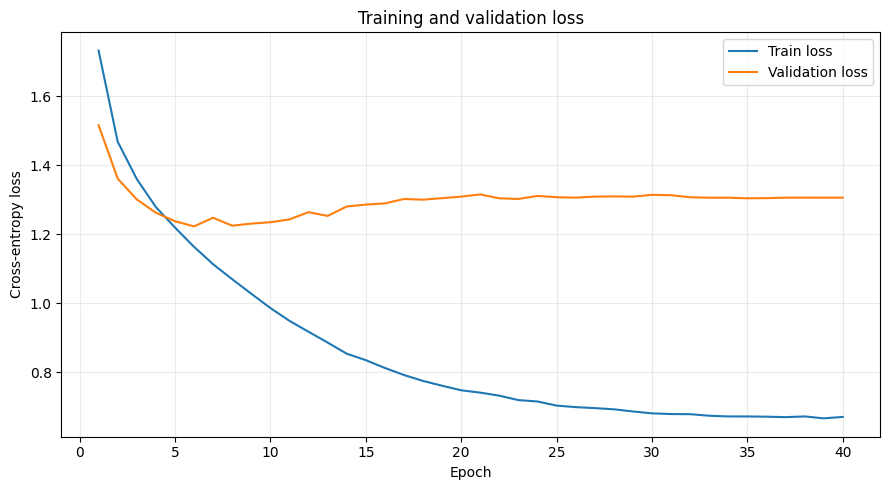

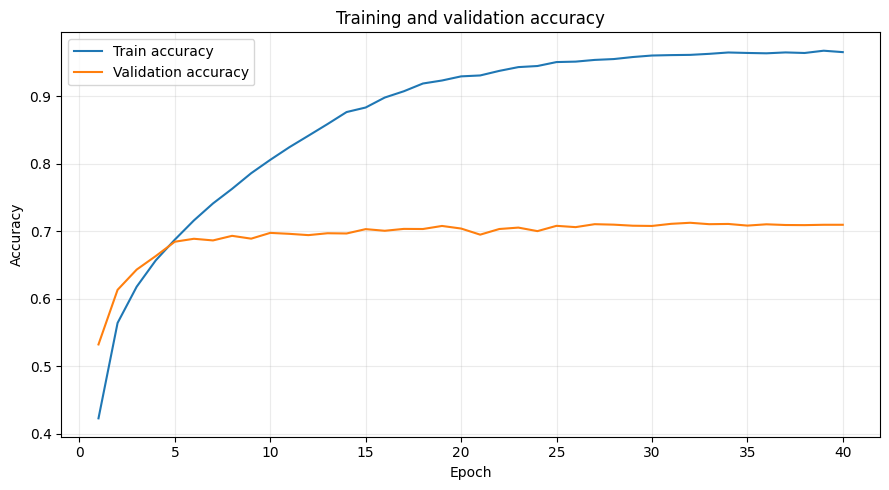

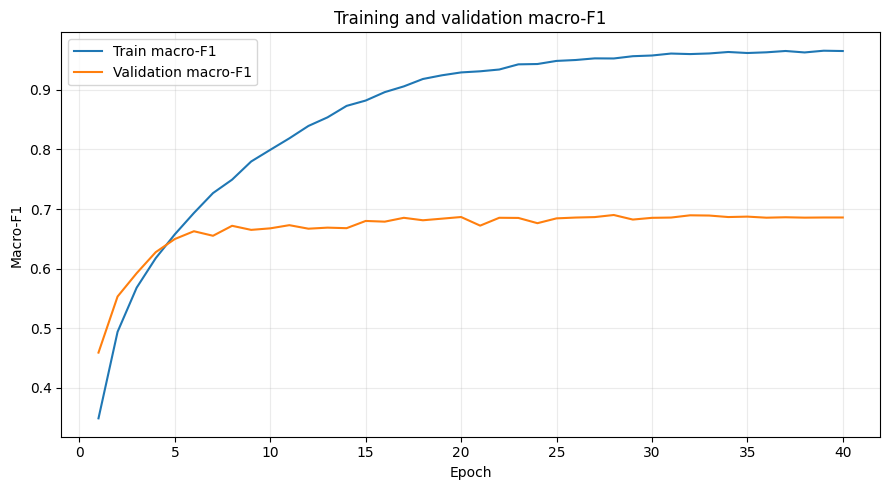

In [15]:
#  Plot training curves
history_df = pd.read_csv(HISTORY_CSV)
display(history_df.tail())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
ax.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Training and validation loss")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_loss_curve.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history_df["epoch"], history_df["train_acc"], label="Train accuracy")
ax.plot(history_df["epoch"], history_df["val_acc"], label="Validation accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Training and validation accuracy")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_accuracy_curve.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history_df["epoch"], history_df["train_macro_f1"], label="Train macro-F1")
ax.plot(history_df["epoch"], history_df["val_macro_f1"], label="Validation macro-F1")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro-F1")
ax.set_title("Training and validation macro-F1")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_macro_f1_curve.png", dpi=180, bbox_inches="tight")
plt.show()

In [16]:
#   BEST checkpoint load before final test
if not BEST_CKPT.exists():
    raise FileNotFoundError("Best checkpoint was not found.")

best_ckpt = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(best_ckpt["model_state_dict"])
model.eval()

print("Loaded best epoch:", int(best_ckpt["epoch"]) + 1)
print("Best validation accuracy:", best_ckpt["best_val_acc"])

Loaded best epoch: 32
Best validation accuracy: 0.7124695228143504


In [17]:
# Final test evaluation with optional TTA
@torch.no_grad()
def predict_loader(model, loader, use_tta=True):
    model.eval()

    all_probs = []
    all_preds = []
    all_targets = []

    for images, labels in loader:
        images = images.to(
            DEVICE,
            non_blocking=True,
            memory_format=torch.channels_last
        )

        with autocast_context():
            logits = model(images)

            if use_tta:
                # Horizontal flip is valid for facial emotion.
                flipped = torch.flip(images, dims=[3])
                logits_flip = model(flipped)
                logits = (logits + logits_flip) / 2.0

            probs = torch.softmax(logits, dim=1)

        preds = probs.argmax(dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_targets.extend(labels.numpy().tolist())

    return (
        np.concatenate(all_probs, axis=0),
        np.array(all_preds),
        np.array(all_targets),
    )

test_probs, test_preds, test_targets = predict_loader(
    model,
    test_loader,
    use_tta=USE_TTA
)

test_acc = accuracy_score(test_targets, test_preds)
test_macro_f1 = f1_score(test_targets, test_preds, average="macro")
test_bal_acc = balanced_accuracy_score(test_targets, test_preds)

print(f"Test accuracy          : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test macro-F1          : {test_macro_f1:.4f}")
print(f"Test balanced accuracy : {test_bal_acc:.4f}")

report_dict = classification_report(
    test_targets,
    test_preds,
    target_names=class_names,
    output_dict=True,
    digits=4
)
report_df = pd.DataFrame(report_dict).T
display(report_df)

report_df.to_csv(REPORT_DIR / "classification_report.csv")

Test accuracy          : 0.7106 (71.06%)
Test macro-F1          : 0.6877
Test balanced accuracy : 0.6985


,precision,recall,f1-score,support
angry,0.602844,0.663883,0.631893,958.000000
disgust,0.578947,0.693694,0.631148,111.000000
fear,0.622074,0.544922,0.580947,1024.000000
happy,0.896884,0.892334,0.894603,1774.000000
neutral,0.683673,0.652068,0.667497,1233.000000
sad,0.583267,0.587009,0.585132,1247.000000
surprise,0.792642,0.855596,0.822917,831.000000
accuracy,0.710644,0.710644,0.710644,0.710644
macro avg,0.680047,0.698501,0.687734,7178.000000
weighted avg,0.710344,0.710644,0.709648,7178.000000


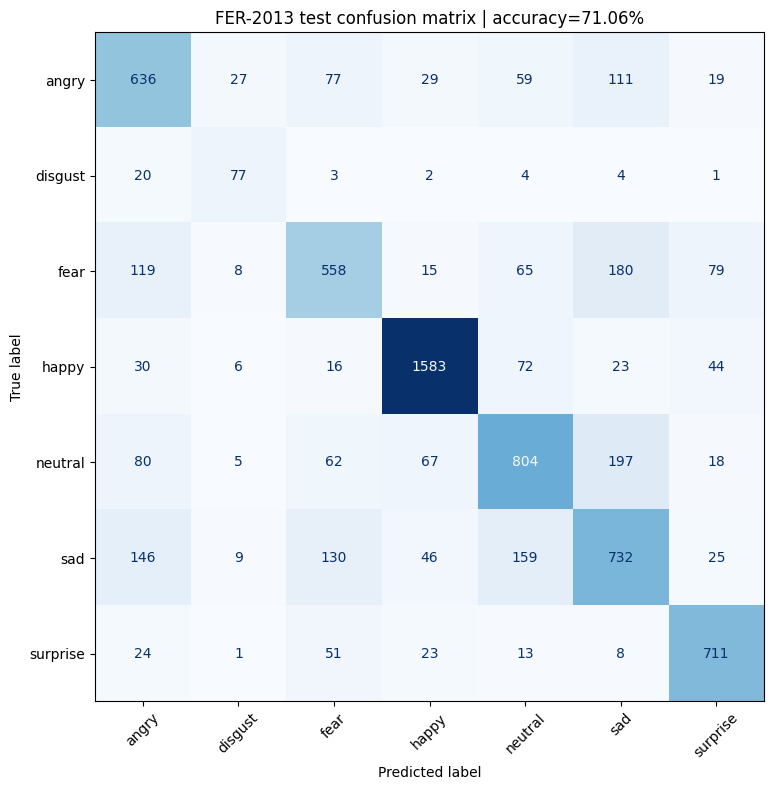

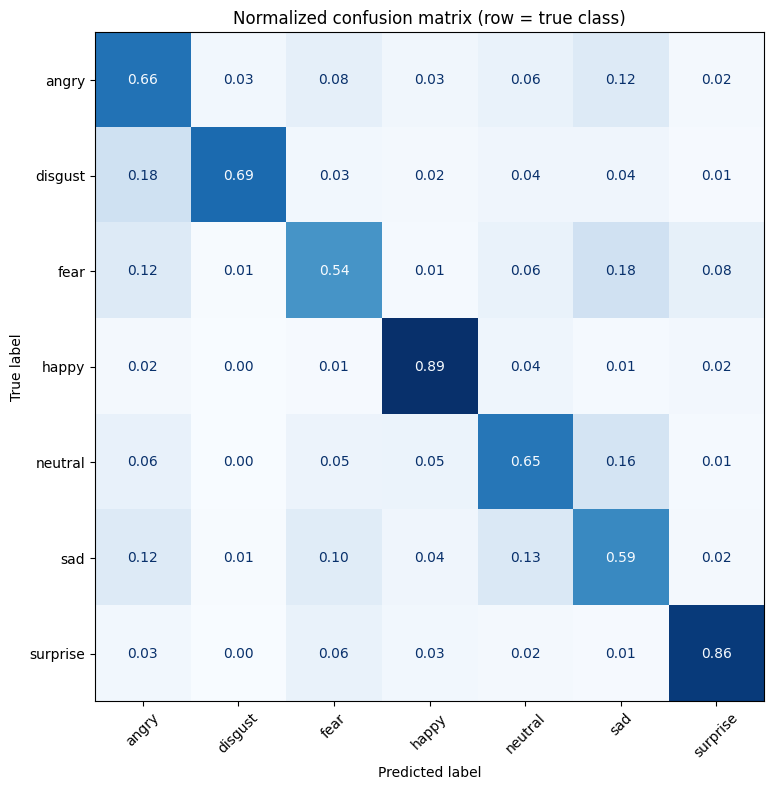

In [18]:
#  Confusion matrices
cm = confusion_matrix(test_targets, test_preds)
cm_norm = confusion_matrix(test_targets, test_preds, normalize="true")

np.savetxt(REPORT_DIR / "confusion_matrix_raw.csv", cm, fmt="%d", delimiter=",")
np.savetxt(REPORT_DIR / "confusion_matrix_normalized.csv", cm_norm, fmt="%.6f", delimiter=",")

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False,
    xticks_rotation=45
)
ax.set_title(f"FER-2013 test confusion matrix | accuracy={test_acc*100:.2f}%")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_confusion_matrix_raw.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
    xticks_rotation=45
)
ax.set_title("Normalized confusion matrix (row = true class)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "06_confusion_matrix_normalized.png", dpi=180, bbox_inches="tight")
plt.show()

,precision,recall,f1-score
angry,0.602844,0.663883,0.631893
disgust,0.578947,0.693694,0.631148
fear,0.622074,0.544922,0.580947
happy,0.896884,0.892334,0.894603
neutral,0.683673,0.652068,0.667497
sad,0.583267,0.587009,0.585132
surprise,0.792642,0.855596,0.822917


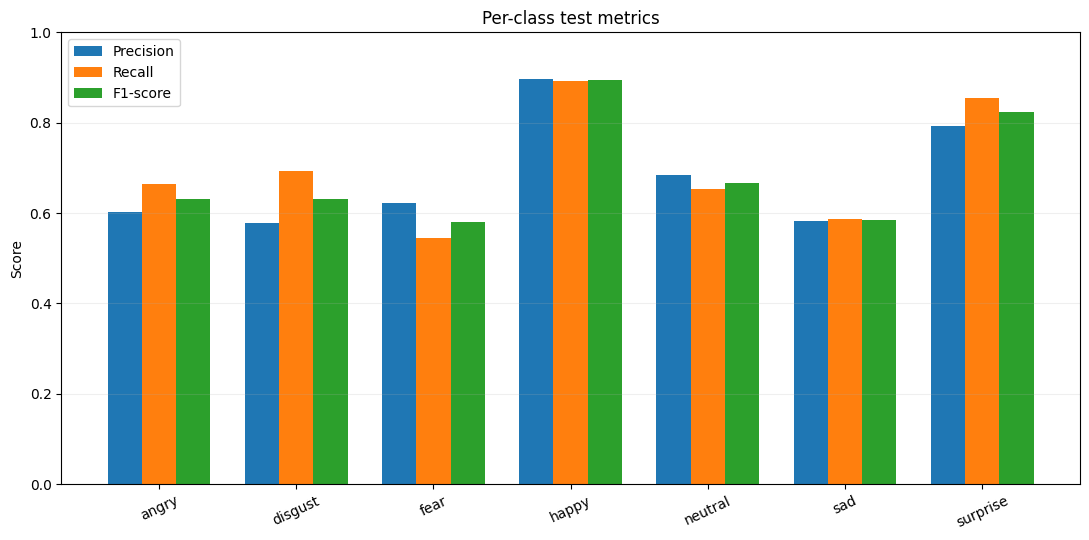

In [19]:
# Per-class Precision / Recall / F1 figure
class_metric_df = report_df.loc[class_names, ["precision", "recall", "f1-score"]].copy()
display(class_metric_df)

x = np.arange(NUM_CLASSES)
w = 0.25

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x - w, class_metric_df["precision"], width=w, label="Precision")
ax.bar(x, class_metric_df["recall"], width=w, label="Recall")
ax.bar(x + w, class_metric_df["f1-score"], width=w, label="F1-score")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=25)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Per-class test metrics")
ax.legend()
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "07_per_class_metrics.png", dpi=180, bbox_inches="tight")
plt.show()

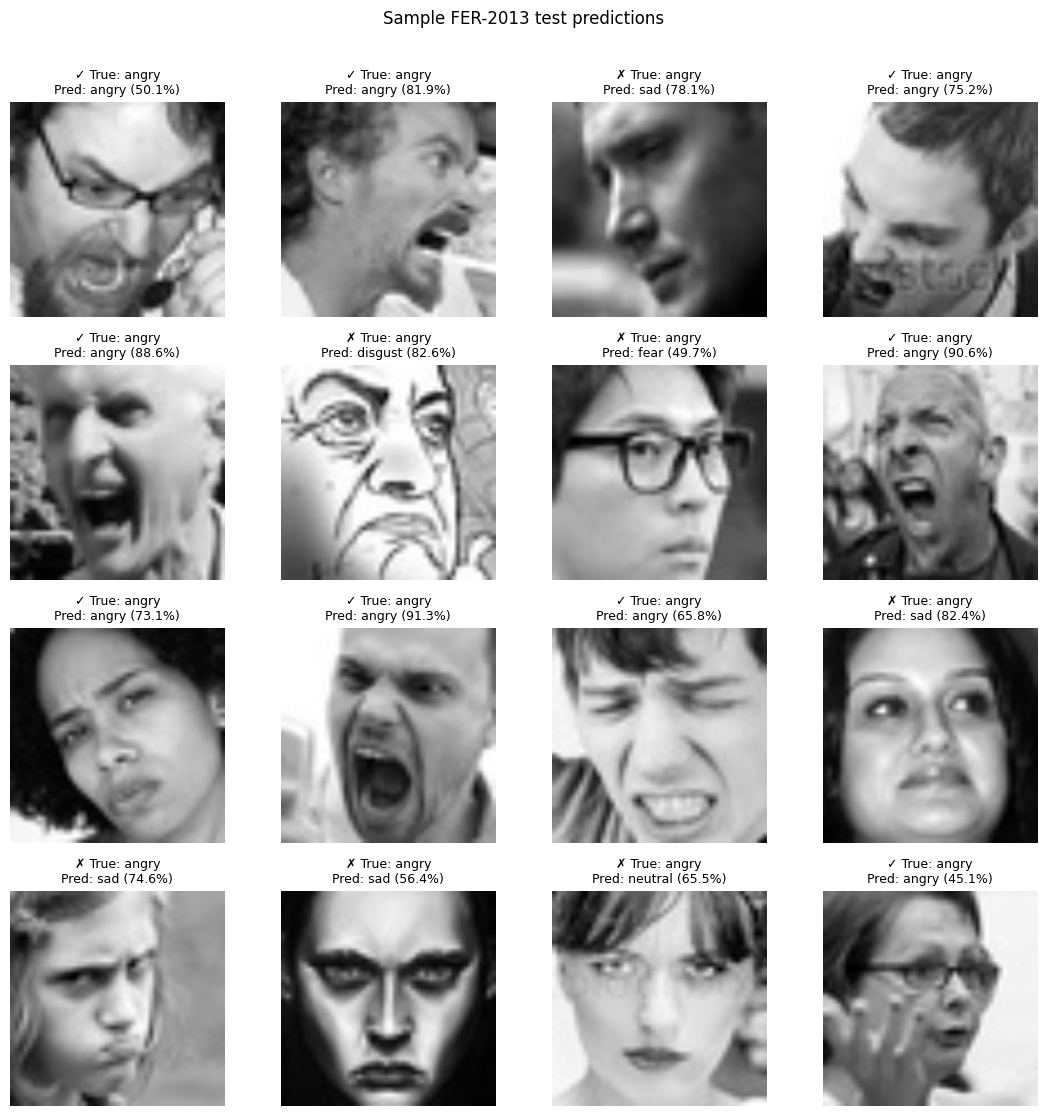

In [20]:
# Visualize sample test predictions
def denormalize_to_gray(tensor):
    t = tensor.detach().cpu().clone()
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    t = (t * std + mean).clamp(0, 1)
    return t[0].numpy()

sample_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False,
    num_workers=0
)
images, labels = next(iter(sample_loader))

images_gpu = images.to(DEVICE, memory_format=torch.channels_last)
with torch.no_grad():
    with autocast_context():
        logits = model(images_gpu)
        if USE_TTA:
            logits = (logits + model(torch.flip(images_gpu, dims=[3]))) / 2
        probs = torch.softmax(logits, dim=1).cpu()

preds = probs.argmax(dim=1)
conf = probs.max(dim=1).values

n_show = min(16, len(images))
fig, axes = plt.subplots(4, 4, figsize=(11, 11))
axes = axes.flatten()

for i in range(n_show):
    axes[i].imshow(denormalize_to_gray(images[i]), cmap="gray")
    true_name = class_names[int(labels[i])]
    pred_name = class_names[int(preds[i])]
    mark = "✓" if int(labels[i]) == int(preds[i]) else "✗"
    axes[i].set_title(
        f"{mark} True: {true_name}\nPred: {pred_name} ({conf[i]*100:.1f}%)",
        fontsize=9
    )
    axes[i].axis("off")

for j in range(n_show, len(axes)):
    axes[j].axis("off")

fig.suptitle("Sample FER-2013 test predictions", y=1.01)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "08_sample_test_predictions.png", dpi=180, bbox_inches="tight")
plt.show()

In [21]:
# Save final deployment files + metadata
torch.save(model.state_dict(), WEIGHTS_ONLY)

metadata = {
    "architecture": "torchvision_convnext_tiny_imagenet1k_v1",
    "classes": class_names,
    "img_size": IMG_SIZE,
    "fer_native_resolution": [48, 48],
    "normalization_mean": IMAGENET_MEAN,
    "normalization_std": IMAGENET_STD,
    "best_epoch": int(best_ckpt["epoch"]) + 1,
    "best_val_accuracy": float(best_ckpt["best_val_acc"]),
    "test_accuracy": float(test_acc),
    "test_macro_f1": float(test_macro_f1),
    "test_balanced_accuracy": float(test_bal_acc),
    "tta_used": bool(USE_TTA),
}

with open(METADATA_JSON, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print("  Retrain/resume checkpoint:", BEST_CKPT)
print("  Latest checkpoint        :", LATEST_CKPT)
print("  Inference weights        :", WEIGHTS_ONLY)
print("  Metadata                 :", METADATA_JSON)
print("  Figures folder           :", FIGURE_DIR)
print("  Reports folder           :", REPORT_DIR)

Saved:
  Retrain/resume checkpoint: /content/drive/MyDrive/EmD/fer2013_convnext_tiny/checkpoints/best_model.pt
  Latest checkpoint        : /content/drive/MyDrive/EmD/fer2013_convnext_tiny/checkpoints/latest_checkpoint.pt
  Inference weights        : /content/drive/MyDrive/EmD/fer2013_convnext_tiny/checkpoints/best_weights_only.pth
  Metadata                 : /content/drive/MyDrive/EmD/fer2013_convnext_tiny/reports/model_metadata.json
  Figures folder           : /content/drive/MyDrive/EmD/fer2013_convnext_tiny/figures
  Reports folder           : /content/drive/MyDrive/EmD/fer2013_convnext_tiny/reports


# Real image upload + MediaPipe face detection

The next cells:
1. upload one or more real images,
2. detect the largest face with MediaPipe,
3. add a small amount of padding,
4. convert the crop to grayscale,
5. optionally reduce it to **48×48** first to mimic FER-2013 resolution,
6. resize to 224×224 for ConvNeXt,
7. predict the emotion and show the top probabilities.

For real-world photos, the 48×48 downsampling is useful for reducing the resolution-domain mismatch with FER-2013. You can compare results with `MATCH_FER_48_RESOLUTION = False` too.

In [22]:
#  MediaPipe face detector helper
import cv2
import mediapipe as mp

def _bbox_from_legacy_mediapipe(rgb):
    with mp.solutions.face_detection.FaceDetection(
        model_selection=1,
        min_detection_confidence=0.50
    ) as detector:
        result = detector.process(rgb)

    if not result.detections:
        return None

    h, w = rgb.shape[:2]
    candidates = []

    for det in result.detections:
        rb = det.location_data.relative_bounding_box
        x = int(rb.xmin * w)
        y = int(rb.ymin * h)
        bw = int(rb.width * w)
        bh = int(rb.height * h)
        area = max(0, bw) * max(0, bh)
        candidates.append((area, x, y, bw, bh))

    _, x, y, bw, bh = max(candidates, key=lambda z: z[0])
    return x, y, bw, bh

def _bbox_from_tasks_mediapipe(rgb):
    from mediapipe.tasks import python as mp_python
    from mediapipe.tasks.python import vision

    detector_path = Path("/content/blaze_face_short_range.tflite")

    if not detector_path.exists():
        url = (
            "https://storage.googleapis.com/mediapipe-models/"
            "face_detector/blaze_face_short_range/float16/latest/"
            "blaze_face_short_range.tflite"
        )
        urllib.request.urlretrieve(url, detector_path)

    base_options = mp_python.BaseOptions(model_asset_path=str(detector_path))
    options = vision.FaceDetectorOptions(
        base_options=base_options,
        min_detection_confidence=0.50
    )

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    with vision.FaceDetector.create_from_options(options) as detector:
        result = detector.detect(mp_image)

    if not result.detections:
        return None

    candidates = []
    for det in result.detections:
        bb = det.bounding_box
        x = int(bb.origin_x)
        y = int(bb.origin_y)
        bw = int(bb.width)
        bh = int(bb.height)
        area = max(0, bw) * max(0, bh)
        candidates.append((area, x, y, bw, bh))

    _, x, y, bw, bh = max(candidates, key=lambda z: z[0])
    return x, y, bw, bh

def detect_largest_face(rgb):
    try:
        if hasattr(mp, "solutions") and hasattr(mp.solutions, "face_detection"):
            return _bbox_from_legacy_mediapipe(rgb)
    except Exception as e:
        print("Legacy MediaPipe detector fallback:", e)

    return _bbox_from_tasks_mediapipe(rgb)

def crop_face_with_padding(rgb, bbox, padding=0.22):
    h, w = rgb.shape[:2]
    x, y, bw, bh = bbox

    pad_x = int(bw * padding)
    pad_y = int(bh * padding)

    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(w, x + bw + pad_x)
    y2 = min(h, y + bh + pad_y)

    return rgb[y1:y2, x1:x2], (x1, y1, x2, y2)

In [23]:
#  Real-image preprocessing + prediction
def prepare_real_face(face_rgb, match_fer_48=True):
    gray = cv2.cvtColor(face_rgb, cv2.COLOR_RGB2GRAY)

    if match_fer_48:
        # Deliberately match FER-2013's native 48×48 resolution first.
        gray = cv2.resize(gray, (48, 48), interpolation=cv2.INTER_AREA)

    pil = Image.fromarray(gray)
    tensor = eval_transform(pil).unsqueeze(0)
    return tensor, gray

@torch.no_grad()
def predict_real_face(face_rgb, match_fer_48=True):
    tensor, fer_gray = prepare_real_face(
        face_rgb,
        match_fer_48=match_fer_48
    )

    tensor = tensor.to(
        DEVICE,
        memory_format=torch.channels_last
    )

    with autocast_context():
        logits = model(tensor)

        if USE_TTA:
            logits = (logits + model(torch.flip(tensor, dims=[3]))) / 2

        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

    order = np.argsort(probs)[::-1]
    return probs, order, fer_gray

Saving download.jpeg to download.jpeg

File: download.jpeg


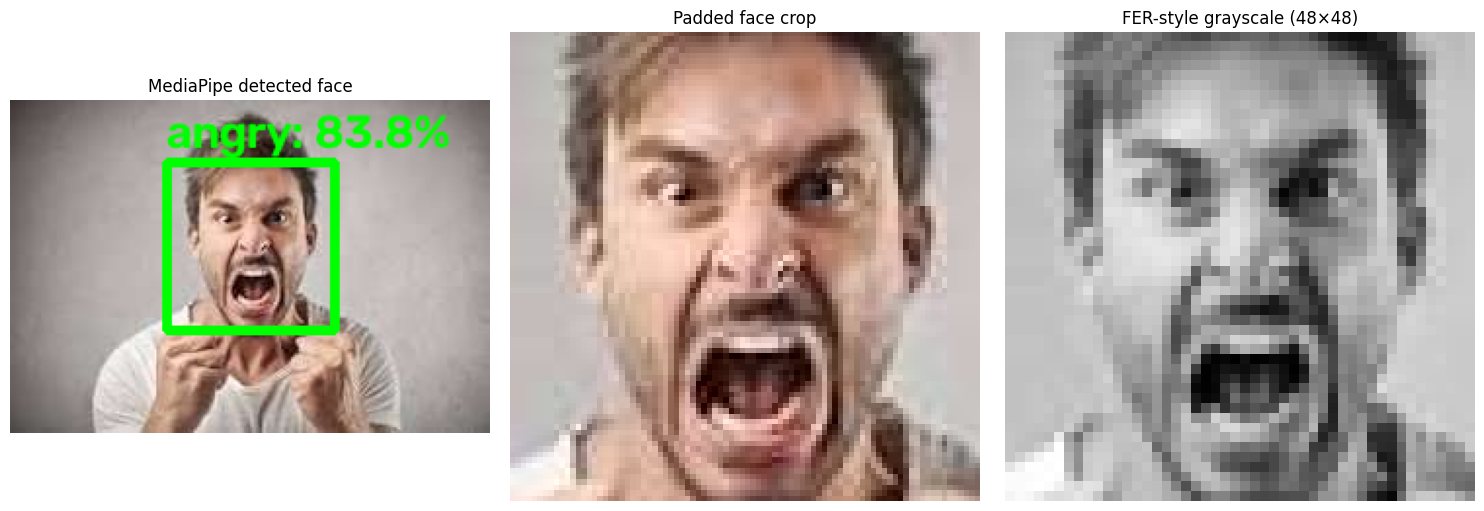

Prediction: angry (83.81%)
Top predictions:
      angry:  83.81%
    disgust:   6.04%
       fear:   5.27%
    neutral:   1.45%
      happy:   1.40%


In [24]:
#  Upload real photo(s) and detect emotion
uploaded = files.upload()

for filename, file_bytes in uploaded.items():
    print("\n" + "=" * 70)
    print("File:", filename)

    arr = np.frombuffer(file_bytes, dtype=np.uint8)
    bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)

    if bgr is None:
        print("Could not read this image.")
        continue

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    bbox = detect_largest_face(rgb)
    if bbox is None:
        print("No face detected by MediaPipe.")
        continue

    face_rgb, padded_box = crop_face_with_padding(
        rgb,
        bbox,
        padding=FACE_PADDING
    )

    probs, order, fer_gray = predict_real_face(
        face_rgb,
        match_fer_48=MATCH_FER_48_RESOLUTION
    )

    pred_idx = int(order[0])
    pred_name = class_names[pred_idx]
    pred_conf = float(probs[pred_idx])

    x1, y1, x2, y2 = padded_box
    drawn = rgb.copy()
    cv2.rectangle(drawn, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(
        drawn,
        f"{pred_name}: {pred_conf*100:.1f}%",
        (x1, max(25, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2,
        cv2.LINE_AA,
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(drawn)
    axes[0].set_title("MediaPipe detected face")
    axes[0].axis("off")

    axes[1].imshow(face_rgb)
    axes[1].set_title("Padded face crop")
    axes[1].axis("off")

    axes[2].imshow(fer_gray, cmap="gray")
    axes[2].set_title(
        "FER-style grayscale" +
        (" (48×48)" if MATCH_FER_48_RESOLUTION else "")
    )
    axes[2].axis("off")

    fig.tight_layout()
    plt.show()

    print(f"Prediction: {pred_name} ({pred_conf*100:.2f}%)")
    print("Top predictions:")
    for idx in order[:5]:
        print(f"  {class_names[int(idx)]:>9s}: {probs[int(idx)]*100:6.2f}%")

angry       0.806
disgust     2.439
fear        0.796
happy       0.600
neutral     0.723
sad         0.733
surprise    0.904

In [25]:
# EXPERIMENT 1 — VALIDATION-SELECTED CLASS PRIOR CORRECTION
val_probs, val_preds_raw, val_targets = predict_loader(
    model,
    val_loader,
    use_tta=True
)

weights_np = class_weights.detach().cpu().numpy()

raw_val_acc = accuracy_score(val_targets, val_preds_raw)

best_alpha = 0.0
best_corrected_acc = raw_val_acc

print(f"Original validation accuracy: {raw_val_acc*100:.2f}%")

# alpha=0 = no correction.
for alpha in np.arange(0.0, 1.51, 0.05):

    corrected_probs = val_probs / (
        weights_np[None, :] ** alpha
    )

    corrected_probs = corrected_probs / corrected_probs.sum(
        axis=1,
        keepdims=True
    )

    corrected_preds = corrected_probs.argmax(axis=1)

    acc = accuracy_score(
        val_targets,
        corrected_preds
    )

    if acc > best_corrected_acc:
        best_corrected_acc = acc
        best_alpha = float(alpha)

print()
print("Best alpha:", best_alpha)
print(
    f"Best corrected validation accuracy: "
    f"{best_corrected_acc*100:.2f}%"
)
print(
    f"Validation gain: "
    f"{(best_corrected_acc-raw_val_acc)*100:.2f} percentage points"
)

# Apply EXACTLY the validation-selected alpha to the TEST set.

corrected_test_probs = test_probs / (
    weights_np[None, :] ** best_alpha
)

corrected_test_probs = corrected_test_probs / corrected_test_probs.sum(
    axis=1,
    keepdims=True
)

corrected_test_preds = corrected_test_probs.argmax(axis=1)

corrected_test_acc = accuracy_score(
    test_targets,
    corrected_test_preds
)

corrected_test_f1 = f1_score(
    test_targets,
    corrected_test_preds,
    average="macro"
)

corrected_test_balanced = balanced_accuracy_score(
    test_targets,
    corrected_test_preds
)

print()
print("============ CORRECTED TEST RESULTS ============")
print(f"Accuracy          : {corrected_test_acc*100:.2f}%")
print(f"Macro F1          : {corrected_test_f1:.4f}")
print(f"Balanced accuracy : {corrected_test_balanced:.4f}")

Original validation accuracy: 71.46%

Best alpha: 0.6000000000000001
Best corrected validation accuracy: 71.75%
Validation gain: 0.30 percentage points

============ CORRECTED TEST RESULTS ============
Accuracy          : 71.04%
Macro F1          : 0.6948
Balanced accuracy : 0.6926


# V2 training starts from

In [26]:

V2_RUN_DIR = DRIVE_DIR / "fer2013_convnext_tiny_v2"
V2_CHECKPOINT_DIR = V2_RUN_DIR / "checkpoints"
V2_FIGURE_DIR = V2_RUN_DIR / "figures"
V2_REPORT_DIR = V2_RUN_DIR / "reports"

for p in [
    V2_RUN_DIR,
    V2_CHECKPOINT_DIR,
    V2_FIGURE_DIR,
    V2_REPORT_DIR
]:
    p.mkdir(parents=True, exist_ok=True)

V2_BEST_CKPT = V2_CHECKPOINT_DIR / "best_model_v2.pt"
V2_LATEST_CKPT = V2_CHECKPOINT_DIR / "latest_v2.pt"

# More images available for actual training
V2_VAL_SPLIT = 0.10

V2_BATCH_SIZE = 64

# 3 head-only epochs + up to 32 fine-tuning epochs
V2_HEAD_EPOCHS = 3
V2_FINETUNE_EPOCHS = 32

V2_PATIENCE = 7

V2_LABEL_SMOOTHING = 0.05
V2_WEIGHT_DECAY = 5e-4

V2_MIXUP_ALPHA = 0.20
V2_MIXUP_PROB = 0.35

print("V2 folder:", V2_RUN_DIR)

V2 folder: /content/drive/MyDrive/EmD/fer2013_convnext_tiny_v2


In [27]:
# V2 DATA + STRONGER REGULARIZATION

v2_train_transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=3),

    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.90, 1.00),
        ratio=(0.95, 1.05)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomAffine(
        degrees=10,
        translate=(0.06, 0.06),
        scale=(0.94, 1.06),
        shear=3,
        fill=0
    ),

    transforms.RandomAutocontrast(p=0.20),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    ),

    transforms.RandomErasing(
        p=0.20,
        scale=(0.02, 0.08),
        ratio=(0.5, 2.0),
        value="random"
    )
])


v2_eval_transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=3),

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])



v2_split_source = datasets.ImageFolder(TRAIN_DIR)

v2_targets = np.array(
    v2_split_source.targets
)

v2_sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=V2_VAL_SPLIT,
    random_state=SEED
)

v2_train_idx, v2_val_idx = next(
    v2_sss.split(
        np.zeros(len(v2_targets)),
        v2_targets
    )
)


v2_train_full = datasets.ImageFolder(
    TRAIN_DIR,
    transform=v2_train_transform
)

v2_val_full = datasets.ImageFolder(
    TRAIN_DIR,
    transform=v2_eval_transform
)

v2_test_ds = datasets.ImageFolder(
    TEST_DIR,
    transform=v2_eval_transform
)

v2_train_ds = Subset(
    v2_train_full,
    v2_train_idx
)

v2_val_ds = Subset(
    v2_val_full,
    v2_val_idx
)


V2_CLASS_NAMES = v2_train_full.classes
V2_NUM_CLASSES = len(V2_CLASS_NAMES)


print("V2 train:", len(v2_train_ds))
print("V2 validation:", len(v2_val_ds))
print("Test:", len(v2_test_ds))
print(V2_CLASS_NAMES)

V2 train: 25838
V2 validation: 2871
Test: 7178
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [28]:
# V2 CLASS WEIGHTS + DATALOADERS

v2_train_targets = v2_targets[v2_train_idx]

v2_class_counts = np.bincount(
    v2_train_targets,
    minlength=V2_NUM_CLASSES
)

v2_raw_weights = 1.0 / (
    v2_class_counts.astype(np.float64) ** 0.25
)

v2_raw_weights = (
    v2_raw_weights /
    v2_raw_weights.mean()
)

v2_class_weights = torch.tensor(
    v2_raw_weights,
    dtype=torch.float32,
    device=DEVICE
)


display(pd.DataFrame({
    "class": V2_CLASS_NAMES,
    "count": v2_class_counts,
    "weight": v2_raw_weights
}))


v2_train_loader = DataLoader(
    v2_train_ds,
    batch_size=V2_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=True
)

v2_val_loader = DataLoader(
    v2_val_ds,
    batch_size=V2_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

v2_test_loader = DataLoader(
    v2_test_ds,
    batch_size=V2_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

print("V2 DataLoaders ready.")

,class,count,weight
0,angry,3596,0.926286
1,disgust,392,1.612051
2,fear,3687,0.920517
3,happy,6493,0.799077
4,neutral,4469,0.877299
5,sad,4347,0.883391
6,surprise,2854,0.981379


V2 DataLoaders ready.


In [29]:

def build_v2_model():

    m = convnext_tiny(
        weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1
    )

    in_features = m.classifier[2].in_features

    m.classifier[2] = nn.Sequential(

        # More dropout than V1
        nn.Dropout(p=0.50),

        nn.Linear(
            in_features,
            V2_NUM_CLASSES
        )
    )

    return m


model_v2 = build_v2_model().to(DEVICE)

model_v2 = model_v2.to(
    memory_format=torch.channels_last
)


criterion_v2 = nn.CrossEntropyLoss(
    weight=v2_class_weights,
    label_smoothing=V2_LABEL_SMOOTHING
)


try:
    scaler_v2 = torch.amp.GradScaler(
        "cuda",
        enabled=True
    )
except:
    scaler_v2 = torch.cuda.amp.GradScaler(
        enabled=True
    )


print("Fresh V2 created.")
print(model_v2.classifier)

Fresh V2 created.
Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=768, out_features=7, bias=True)
  )
)


In [30]:
# V2 TRAINING FUNCTIONS

def v2_autocast():

    try:
        return torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=True
        )

    except:
        return torch.cuda.amp.autocast(
            enabled=True
        )


def v2_mixup(images, labels):

    lam = np.random.beta(
        V2_MIXUP_ALPHA,
        V2_MIXUP_ALPHA
    )

    index = torch.randperm(
        images.size(0),
        device=images.device
    )

    mixed = (
        lam * images
        +
        (1.0 - lam) * images[index]
    )

    return (
        mixed,
        labels,
        labels[index],
        lam
    )


def train_v2_epoch(
    model,
    loader,
    optimizer,
    use_mixup=True
):

    model.train()

    running_loss = 0.0

    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True,
            memory_format=torch.channels_last
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )


        do_mixup = (
            use_mixup
            and
            random.random() < V2_MIXUP_PROB
        )


        if do_mixup:

            mixed, ya, yb, lam = v2_mixup(
                images,
                labels
            )

            with v2_autocast():

                logits = model(mixed)

                loss = (
                    lam * criterion_v2(
                        logits,
                        ya
                    )
                    +
                    (1-lam) * criterion_v2(
                        logits,
                        yb
                    )
                )

        else:

            with v2_autocast():

                logits = model(images)

                loss = criterion_v2(
                    logits,
                    labels
                )


        scaler_v2.scale(
            loss
        ).backward()


        scaler_v2.unscale_(
            optimizer
        )


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )


        scaler_v2.step(
            optimizer
        )

        scaler_v2.update()


        running_loss += (
            loss.item()
            *
            labels.size(0)
        )


    return (
        running_loss /
        len(loader.dataset)
    )


@torch.no_grad()
def evaluate_v2(model, loader):

    model.eval()

    running_loss = 0

    targets = []
    preds = []


    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True,
            memory_format=torch.channels_last
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        with v2_autocast():

            logits = model(images)

            loss = criterion_v2(
                logits,
                labels
            )


        prediction = logits.argmax(1)


        running_loss += (
            loss.item()
            *
            labels.size(0)
        )

        targets.extend(
            labels.cpu().numpy()
        )

        preds.extend(
            prediction.cpu().numpy()
        )


    loss = (
        running_loss /
        len(loader.dataset)
    )

    accuracy = accuracy_score(
        targets,
        preds
    )

    f1 = f1_score(
        targets,
        preds,
        average="macro"
    )

    return loss, accuracy, f1

In [31]:

# Freeze ConvNeXt feature extractor
for param in model_v2.features.parameters():
    param.requires_grad = False

# Classifier remains trainable
for param in model_v2.classifier.parameters():
    param.requires_grad = True


v2_head_optimizer = torch.optim.AdamW(
    model_v2.classifier.parameters(),
    lr=3e-4,
    weight_decay=V2_WEIGHT_DECAY
)


print("Starting Stage 1...")


for epoch in range(V2_HEAD_EPOCHS):

    train_loss = train_v2_epoch(
        model_v2,
        v2_train_loader,
        v2_head_optimizer,
        use_mixup=False
    )

    val_loss, val_acc, val_f1 = evaluate_v2(
        model_v2,
        v2_val_loader
    )


    print(
        f"HEAD {epoch+1}/{V2_HEAD_EPOCHS} | "
        f"train loss {train_loss:.4f} | "
        f"val loss {val_loss:.4f} | "
        f"val acc {val_acc*100:.2f}% | "
        f"val F1 {val_f1:.4f}"
    )

Starting Stage 1...
HEAD 1/3 | train loss 1.7532 | val loss 1.5975 | val acc 44.86% | val F1 0.3540
HEAD 2/3 | train loss 1.6182 | val loss 1.5439 | val acc 46.19% | val F1 0.3692
HEAD 3/3 | train loss 1.5857 | val loss 1.5056 | val acc 48.42% | val F1 0.3862


In [32]:

for param in model_v2.features.parameters():
    param.requires_grad = False



for block_index in [5, 6, 7]:

    for param in model_v2.features[
        block_index
    ].parameters():

        param.requires_grad = True


for param in model_v2.classifier.parameters():
    param.requires_grad = True



v2_backbone_params = []

for block_index in [5, 6, 7]:

    v2_backbone_params += list(
        model_v2.features[
            block_index
        ].parameters()
    )


v2_optimizer = torch.optim.AdamW(

    [
        {
            "params": v2_backbone_params,
            "lr": 1e-5
        },

        {
            "params": model_v2.classifier.parameters(),
            "lr": 1e-4
        }
    ],

    weight_decay=V2_WEIGHT_DECAY
)


v2_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    v2_optimizer,
    T_max=V2_FINETUNE_EPOCHS,
    eta_min=1e-7
)


v2_best_acc = 0.0
v2_best_f1 = 0.0

v2_patience_counter = 0

v2_history = []


print("Starting V2 fine-tuning...")


for epoch in range(V2_FINETUNE_EPOCHS):

    start = time.time()


    train_loss = train_v2_epoch(
        model_v2,
        v2_train_loader,
        v2_optimizer,
        use_mixup=True
    )


    val_loss, val_acc, val_f1 = evaluate_v2(
        model_v2,
        v2_val_loader
    )


    v2_scheduler.step()


    row = {

        "epoch": epoch + 1,

        "train_loss": train_loss,

        "val_loss": val_loss,

        "val_acc": val_acc,

        "val_f1": val_f1,

        "lr_backbone":
            v2_optimizer.param_groups[0]["lr"],

        "lr_head":
            v2_optimizer.param_groups[1]["lr"],

        "minutes":
            (time.time() - start) / 60
    }


    v2_history.append(row)


    improved = val_acc > v2_best_acc


    if improved:

        v2_best_acc = val_acc
        v2_best_f1 = val_f1

        v2_patience_counter = 0


        torch.save({

            "epoch": epoch,

            "model_state_dict":
                model_v2.state_dict(),

            "optimizer_state_dict":
                v2_optimizer.state_dict(),

            "scheduler_state_dict":
                v2_scheduler.state_dict(),

            "scaler_state_dict":
                scaler_v2.state_dict(),

            "best_val_acc":
                v2_best_acc,

            "best_val_f1":
                v2_best_f1,

            "history":
                v2_history,

            "class_names":
                V2_CLASS_NAMES

        }, V2_BEST_CKPT)


        mark = " <-- BEST SAVED"


    else:

        v2_patience_counter += 1

        mark = ""



    torch.save({

        "epoch": epoch,

        "model_state_dict":
            model_v2.state_dict(),

        "optimizer_state_dict":
            v2_optimizer.state_dict(),

        "scheduler_state_dict":
            v2_scheduler.state_dict(),

        "scaler_state_dict":
            scaler_v2.state_dict(),

        "best_val_acc":
            v2_best_acc,

        "best_val_f1":
            v2_best_f1,

        "history":
            v2_history,

        "class_names":
            V2_CLASS_NAMES

    }, V2_LATEST_CKPT)


    pd.DataFrame(
        v2_history
    ).to_csv(
        V2_REPORT_DIR /
        "v2_training_history.csv",
        index=False
    )


    print(

        f"V2 Epoch {epoch+1:02d}/"
        f"{V2_FINETUNE_EPOCHS} | "

        f"train loss {train_loss:.4f} | "

        f"val loss {val_loss:.4f} | "

        f"val acc {val_acc*100:.2f}% | "

        f"val F1 {val_f1:.4f} | "

        f"{row['minutes']:.1f} min"

        f"{mark}"
    )


    if v2_patience_counter >= V2_PATIENCE:

        print(
            "Early stopping:"
            f" no improvement for "
            f"{V2_PATIENCE} epochs."
        )

        break


print()
print(
    f"BEST V2 VALIDATION ACCURACY: "
    f"{v2_best_acc*100:.2f}%"
)

print(
    f"BEST V2 VALIDATION F1: "
    f"{v2_best_f1:.4f}"
)

print(
    "Saved:",
    V2_BEST_CKPT
)

Starting V2 fine-tuning...
V2 Epoch 01/32 | train loss 1.4676 | val loss 1.2977 | val acc 56.70% | val F1 0.4604 | 1.8 min <-- BEST SAVED
V2 Epoch 02/32 | train loss 1.3601 | val loss 1.2261 | val acc 59.25% | val F1 0.5018 | 1.8 min <-- BEST SAVED
V2 Epoch 03/32 | train loss 1.2957 | val loss 1.1808 | val acc 62.17% | val F1 0.5481 | 2.0 min <-- BEST SAVED
V2 Epoch 04/32 | train loss 1.2463 | val loss 1.1470 | val acc 63.64% | val F1 0.5773 | 2.0 min <-- BEST SAVED
V2 Epoch 05/32 | train loss 1.2178 | val loss 1.1179 | val acc 64.75% | val F1 0.5942 | 2.0 min <-- BEST SAVED
V2 Epoch 06/32 | train loss 1.1859 | val loss 1.1068 | val acc 65.73% | val F1 0.6069 | 2.0 min <-- BEST SAVED
V2 Epoch 07/32 | train loss 1.1780 | val loss 1.0941 | val acc 65.87% | val F1 0.6045 | 2.0 min <-- BEST SAVED
V2 Epoch 08/32 | train loss 1.1589 | val loss 1.0837 | val acc 66.04% | val F1 0.6106 | 2.0 min <-- BEST SAVED
V2 Epoch 09/32 | train loss 1.1211 | val loss 1.0799 | val acc 66.04% | val F1 0.6074